In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/heart_attack_prediction_dataset.csv")

In [3]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,8763.0,53.707977,21.249509,18.000000,35.000000,54.000000,72.000000,90.000000
Cholesterol,8763.0,259.877211,80.863276,120.000000,192.000000,259.000000,330.000000,400.000000
Heart Rate,8763.0,75.021682,20.550948,40.000000,57.000000,75.000000,93.000000,110.000000
Diabetes,8763.0,0.652288,0.476271,0.000000,0.000000,1.000000,1.000000,1.000000
Family History,8763.0,0.492982,0.499979,0.000000,0.000000,0.000000,1.000000,1.000000
Smoking,8763.0,0.896839,0.304186,0.000000,1.000000,1.000000,1.000000,1.000000
Obesity,8763.0,0.501426,0.500026,0.000000,0.000000,1.000000,1.000000,1.000000
Alcohol Consumption,8763.0,0.598083,0.490313,0.000000,0.000000,1.000000,1.000000,1.000000
Exercise Hours Per Week,8763.0,10.014284,5.783745,0.002442,4.981579,10.069559,15.050018,19.998709
Previous Heart Problems,8763.0,0.495835,0.500011,0.000000,0.000000,0.000000,1.000000,1.000000


In [10]:
df.isnull().sum().sort_values(ascending=False)

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

In [11]:
df.nunique().sort_values(ascending=False)

Patient ID                         8763
Exercise Hours Per Week            8763
Sedentary Hours Per Day            8763
BMI                                8763
Income                             8615
Blood Pressure                     3915
Triglycerides                       771
Cholesterol                         281
Age                                  73
Heart Rate                           71
Country                              20
Stress Level                         10
Physical Activity Days Per Week       8
Sleep Hours Per Day                   7
Continent                             6
Diet                                  3
Sex                                   2
Diabetes                              2
Obesity                               2
Smoking                               2
Family History                        2
Alcohol Consumption                   2
Medication Use                        2
Previous Heart Problems               2
Hemisphere                            2


In [12]:
df["Heart Attack Risk"].value_counts(normalize=True)

Heart Attack Risk
0    0.641789
1    0.358211
Name: proportion, dtype: float64

In [13]:
# definisi kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['Patient ID',
 'Sex',
 'Blood Pressure',
 'Diet',
 'Country',
 'Continent',
 'Hemisphere']

In [14]:
# definisi kolom numerikal
num_cols = df.select_dtypes(include= np.number).columns.tolist()
num_cols

['Age',
 'Cholesterol',
 'Heart Rate',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Exercise Hours Per Week',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Sedentary Hours Per Day',
 'Income',
 'BMI',
 'Triglycerides',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'Heart Attack Risk']

<Axes: ylabel='count'>

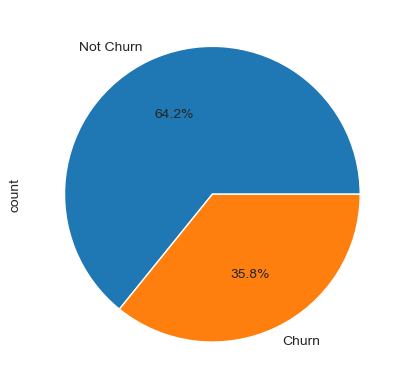

In [15]:
df["Heart Attack Risk"].value_counts().plot.pie(
    autopct = "%1.1f%%",
    labels = ["Not Churn", "Churn"]
)

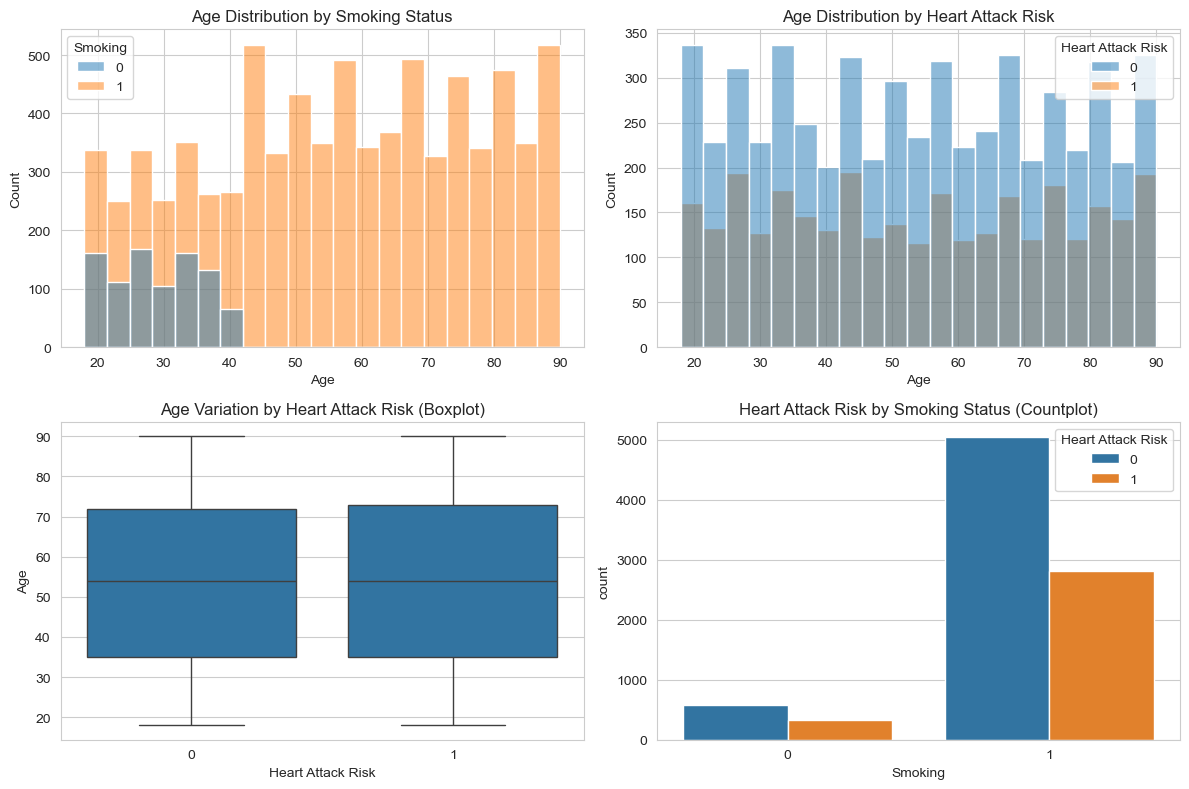

In [16]:
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
sns.histplot(data = df, x = "Age", hue =  "Smoking")
plt.title("Age Distribution by Smoking Status")

plt.subplot(2,2,2)
sns.histplot(data = df, x = "Age", hue =  "Heart Attack Risk")
plt.title("Age Distribution by Heart Attack Risk")

plt.subplot(2,2,3)
sns.boxplot(data=df, x="Heart Attack Risk", y="Age")
plt.title("Age Variation by Heart Attack Risk (Boxplot)")

plt.subplot(2,2,4)
sns.countplot(data = df, x ="Smoking", hue="Heart Attack Risk")
plt.title("Heart Attack Risk by Smoking Status (Countplot)")

plt.tight_layout()

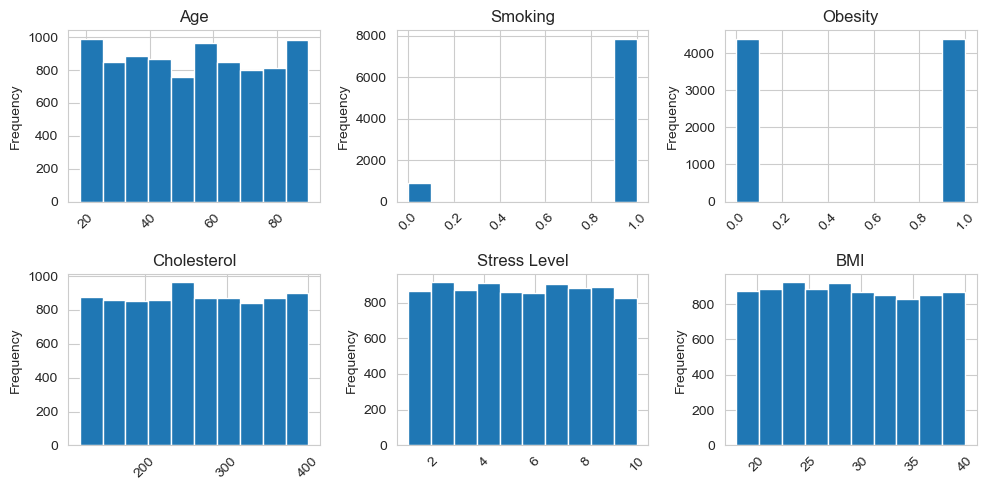

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(10,5))
axes = axes.flatten()
cols = ["Age", "Smoking", "Obesity", "Cholesterol", "Stress Level", "BMI"]

for i, col in enumerate(cols):
    df[col].plot(kind="hist", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

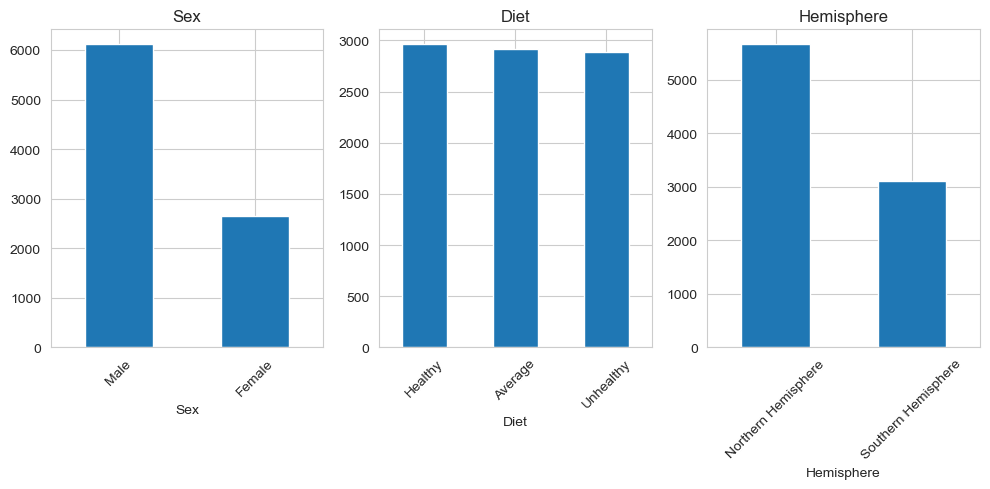

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(10,5))
axes = axes.flatten()
cols = ["Sex", "Diet", "Hemisphere"]

for i, col in enumerate(cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

<Axes: >

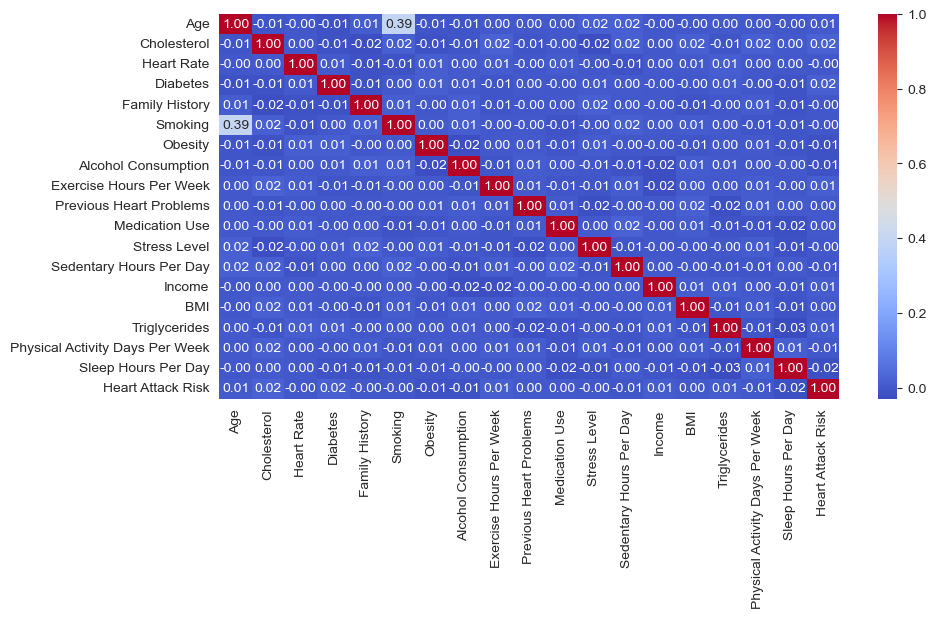

In [19]:
# Cek Korelasi
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

<Axes: >

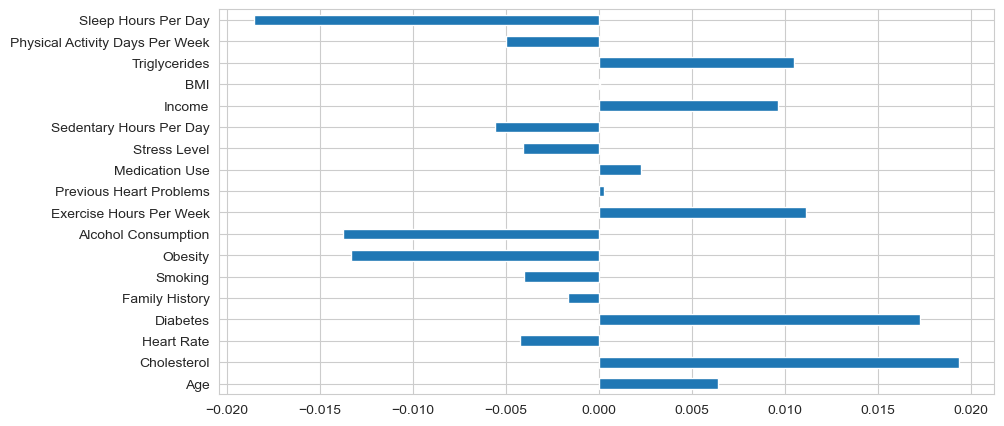

In [20]:
df.corr(numeric_only=True)["Heart Attack Risk"][:-1].plot(kind="barh", figsize=(10,5))

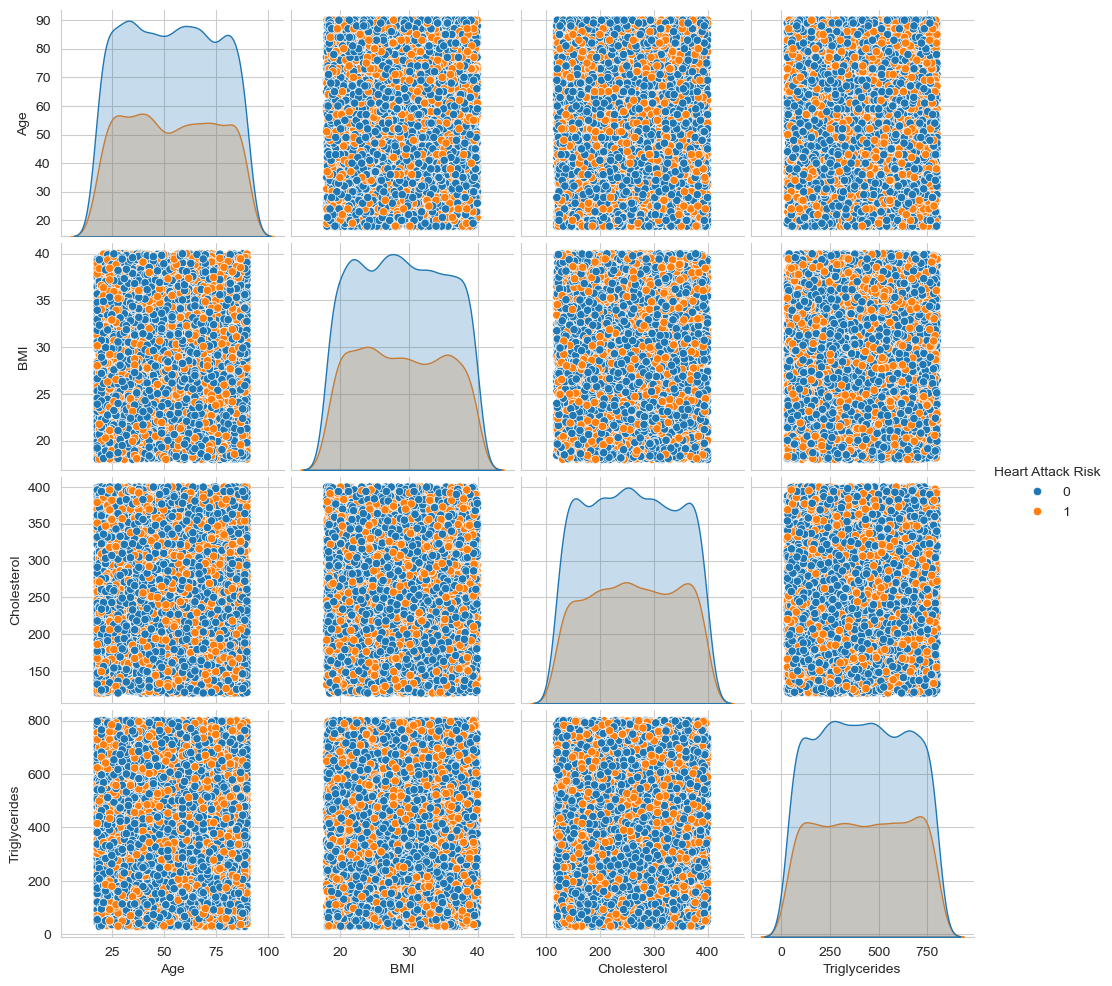

In [21]:
cols = ["Age", "BMI", "Cholesterol", "Triglycerides", "Heart Attack Risk"]

sns.pairplot(df[cols], hue="Heart Attack Risk")
plt.show()

# Handling Missing Values, Duplicates, Outlier

In [22]:
missing = df.isna().sum().sort_values(ascending = False)
missing_percentage = (missing / len(df)) * 100
missing_percentage

Patient ID                         0.0
Age                                0.0
Sex                                0.0
Cholesterol                        0.0
Blood Pressure                     0.0
Heart Rate                         0.0
Diabetes                           0.0
Family History                     0.0
Smoking                            0.0
Obesity                            0.0
Alcohol Consumption                0.0
Exercise Hours Per Week            0.0
Diet                               0.0
Previous Heart Problems            0.0
Medication Use                     0.0
Stress Level                       0.0
Sedentary Hours Per Day            0.0
Income                             0.0
BMI                                0.0
Triglycerides                      0.0
Physical Activity Days Per Week    0.0
Sleep Hours Per Day                0.0
Country                            0.0
Continent                          0.0
Hemisphere                         0.0
Heart Attack Risk        

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
# cek data outlier
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

outlier_summary

{'Age': 0,
 'Cholesterol': 0,
 'Heart Rate': 0,
 'Diabetes': 0,
 'Family History': 0,
 'Smoking': 904,
 'Obesity': 0,
 'Alcohol Consumption': 0,
 'Exercise Hours Per Week': 0,
 'Previous Heart Problems': 0,
 'Medication Use': 0,
 'Stress Level': 0,
 'Sedentary Hours Per Day': 0,
 'Income': 0,
 'BMI': 0,
 'Triglycerides': 0,
 'Physical Activity Days Per Week': 0,
 'Sleep Hours Per Day': 0,
 'Heart Attack Risk': 0}